# 3.4 Построение индивидуальной траектории обучения

**Агент** запрашивает у пользователя:
1. Уже изученные предметы (дисциплины)
2. Общие временные рамки для прохождения курса
3. Доступное время в день (часов)

На основе кластеров параллельного и последовательного изучения (Модуль Б)  
агент строит **индивидуальный план** и визуализирует его в виде диаграммы Ганта.

In [2]:
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

from src.config import WORDS_PER_MINUTE, COMPLEXITY_MULTIPLIERS, MEDIA_TIME_MIN, VIDEO_TIME_MIN, QUESTION_TIME_MIN
from src.db import load_labelled_materials
from src.trajectory_graph import export_trajectory_graph

REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)
print('Импорты загружены. Python', sys.version)

Импорты загружены. Python 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


## 1. Загрузка данных

In [3]:
df = load_labelled_materials()

def estimate_material_time(row):
    wc   = max(float(row.get('word_count') or 0), 0)
    mult = COMPLEXITY_MULTIPLIERS.get(int(row.get('complexity_cluster', 1)), 1.4)
    t_base      = wc / WORDS_PER_MINUTE
    t_images    = float(row.get('has_images', 0) or 0)    * MEDIA_TIME_MIN
    t_videos    = float(row.get('has_videos', 0) or 0)    * VIDEO_TIME_MIN
    t_questions = float(row.get('has_questions', 0) or 0) * QUESTION_TIME_MIN
    return round(t_base * mult + t_images + t_videos + t_questions, 2)

df['time_min'] = df.apply(estimate_material_time, axis=1)

all_subjects = sorted(df['subject'].dropna().unique().tolist())
print(f'Материалов: {len(df)}, предметов: {len(all_subjects)}')
print('Доступные предметы:', all_subjects)

Материалов: 8, предметов: 5
Доступные предметы: ['Анализ данных', 'Естествознание / Окружающий мир', 'Информатика', 'Окружающий мир', 'Экология']


## 2. Ввод данных пользователя (интерактивные виджеты)

In [4]:
# ── Виджеты ввода ────────────────────────────────────────────
style = {'description_width': '220px'}
layout_wide = widgets.Layout(width='500px')

w_studied = widgets.SelectMultiple(
    options=all_subjects,
    value=[],
    description='Уже изученные предметы:',
    style=style,
    layout=widgets.Layout(width='500px', height='150px')
)

w_daily_hours = widgets.FloatSlider(
    value=3.0, min=0.5, max=12.0, step=0.5,
    description='Часов в день:',
    style=style, layout=layout_wide,
    readout_format='.1f'
)

w_total_weeks = widgets.IntSlider(
    value=16, min=1, max=52, step=1,
    description='Всего недель на курс:',
    style=style, layout=layout_wide
)

w_start = widgets.DatePicker(
    description='Дата начала:',
    value=datetime.today().date(),
    style=style, layout=layout_wide
)

w_priority = widgets.RadioButtons(
    options=['Быстрее (больше параллелизма)', 'Глубже (последовательно, без спешки)'],
    value='Быстрее (больше параллелизма)',
    description='Приоритет:',
    style=style
)

btn_build = widgets.Button(
    description='Построить траекторию',
    button_style='success',
    layout=widgets.Layout(width='220px', height='36px')
)

output_area = widgets.Output()

display(
    widgets.HTML('<h3>Параметры обучения</h3>'),
    w_studied,
    w_daily_hours,
    w_total_weeks,
    w_start,
    w_priority,
    btn_build,
    output_area
)

HTML(value='<h3>Параметры обучения</h3>')

SelectMultiple(description='Уже изученные предметы:', layout=Layout(height='150px', width='500px'), options=('…

FloatSlider(value=3.0, description='Часов в день:', layout=Layout(width='500px'), max=12.0, min=0.5, readout_f…

IntSlider(value=16, description='Всего недель на курс:', layout=Layout(width='500px'), max=52, min=1, style=Sl…

DatePicker(value=datetime.date(2026, 4, 23), description='Дата начала:', layout=Layout(width='500px'), step=1,…

RadioButtons(description='Приоритет:', options=('Быстрее (больше параллелизма)', 'Глубже (последовательно, без…

Button(button_style='success', description='Построить траекторию', layout=Layout(height='36px', width='220px')…

Output()

## 3. Алгоритм построения траектории и визуализация

In [5]:
def build_trajectory(df, studied_subjects, daily_hours, total_weeks, start_date, parallel_mode=True):
    """
    Строит индивидуальную траекторию.
    
    parallel_mode=True  → материалы из разных parallel_cluster идут одновременно
    parallel_mode=False → полностью последовательный план
    """
    # Исключаем уже изученные предметы
    df_todo = df[~df['subject'].isin(studied_subjects)].copy()
    if df_todo.empty:
        return pd.DataFrame(), 0

    deadline = start_date + timedelta(weeks=total_weeks)
    daily_min = daily_hours * 60

    gantt_rows = []
    current_date = start_date

    if parallel_mode:
        # Группируем по parallel_cluster (одновременные потоки)
        for cluster_id in sorted(df_todo['parallel_cluster'].unique()):
            cluster_df = df_todo[df_todo['parallel_cluster'] == cluster_id]

            # Внутри кластера — последовательно по sequential_cluster
            max_end = current_date
            for subj in sorted(cluster_df['subject'].unique()):
                subj_df = cluster_df[cluster_df['subject'] == subj]
                total_min = subj_df['time_min'].sum()
                days_needed = max(1, int(np.ceil(total_min / daily_min)))
                end_date = current_date + timedelta(days=days_needed)
                if end_date > max_end:
                    max_end = end_date
                gantt_rows.append({
                    'Предмет': subj,
                    'Поток': f'Кластер {cluster_id}',
                    'Начало': current_date,
                    'Конец': end_date,
                    'Часов': round(total_min / 60, 1),
                    'Материалов': len(subj_df),
                    'Статус': '✓ изучен' if subj in studied_subjects else 'к изучению'
                })
            current_date = max_end  # Следующий кластер начинается после завершения текущего
    else:
        # Последовательный план по sequential_cluster
        df_ordered = df_todo.sort_values(['sequential_cluster', 'subject'])
        for subj in df_ordered['subject'].unique():
            subj_df = df_ordered[df_ordered['subject'] == subj]
            total_min = subj_df['time_min'].sum()
            days_needed = max(1, int(np.ceil(total_min / daily_min)))
            end_date = current_date + timedelta(days=days_needed)
            gantt_rows.append({
                'Предмет': subj,
                'Поток': 'Последовательный',
                'Начало': current_date,
                'Конец': end_date,
                'Часов': round(total_min / 60, 1),
                'Материалов': len(subj_df),
                'Статус': 'к изучению'
            })
            current_date = end_date

    gantt_df = pd.DataFrame(gantt_rows)
    total_days = (current_date - start_date).days
    return gantt_df, total_days


def visualize_trajectory(gantt_df, total_days, daily_hours, start_date, deadline, studied_subjects):
    if gantt_df.empty:
        print('Нет предметов для изучения!')
        return

    # Plotly Gantt
    fig = px.timeline(
        gantt_df,
        x_start='Начало',
        x_end='Конец',
        y='Предмет',
        color='Поток',
        text='Часов',
        title=f'Индивидуальная траектория обучения ({daily_hours} ч/день | {total_days} дней)',
        labels={'Предмет': 'Дисциплина', 'Поток': 'Группа изучения'},
        color_discrete_sequence=px.colors.qualitative.Set2,
        hover_data=['Материалов', 'Часов']
    )
    fig.update_yaxes(autorange='reversed')
    # Дедлайн
    fig.add_shape(
        type='line', x0=deadline, x1=deadline, y0=0, y1=1,
        xref='x', yref='paper',
        line=dict(color='red', dash='dash')
    )
    fig.add_annotation(
        x=deadline, y=1, xref='x', yref='paper',
        text='Дедлайн', showarrow=False, yshift=10, font=dict(color='red')
    )
    fig.update_layout(
        height=max(350, 55 * len(gantt_df)),
        font=dict(size=12),
        plot_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='#eeeeee')
    )
    fig.update_traces(textposition='inside')
    out_path = REPORTS / 'trajectory.html'
    fig.write_html(str(out_path))

    graph_html = REPORTS / 'trajectory_graph.html'
    graph_png = REPORTS / 'trajectory_graph.png'
    export_trajectory_graph(
        gantt_df,
        out_html=graph_html,
        out_png=graph_png,
        title='???? ?????????????? ?????????? ????????'
    )
    fig.show()

    # Текстовый план
    print('\n=== ПЛАН ОБУЧЕНИЯ ===')
    print(f'Дата начала:       {start_date.date()}')
    print(f'Дедлайн:           {deadline.date()}')
    print(f'Доступно часов/дн: {daily_hours}')
    print(f'Расчётных дней:    {total_days}')
    fits = (start_date + timedelta(days=total_days)) <= deadline
    print(f'Укладывается в срок: {"ДА ✓" if fits else "НЕТ ✗ — нужно больше времени в день"}')
    if studied_subjects:
        print(f'\nУже изучено: {", ".join(studied_subjects)}')
    print('\nПредмет → дней:')
    for _, row in gantt_df.iterrows():
        days = (row['Конец'] - row['Начало']).days
        print(f'  {row["Предмет"]:30s} {days:3d} дн  ({row["Часов"]} ч, {row["Материалов"]} матер.)')

    gantt_df.to_csv(REPORTS / 'trajectory_plan.csv', index=False, encoding='utf-8')
    print(f'\nСохранено: reports/trajectory.html, trajectory_plan.csv')

print('Функции построения траектории готовы.')

Функции построения траектории готовы.


In [6]:
# ── Обработчик кнопки ────────────────────────────────────────
def on_build_click(b):
    with output_area:
        clear_output(wait=True)
        studied = list(w_studied.value)
        daily_h = w_daily_hours.value
        n_weeks = w_total_weeks.value
        start   = datetime.combine(w_start.value, datetime.min.time())
        deadline = start + timedelta(weeks=n_weeks)
        parallel_mode = 'параллел' in w_priority.value.lower()

        print(f'Параметры: {daily_h} ч/день | {n_weeks} нед | старт {start.date()} | '
              f'режим: {"параллельный" if parallel_mode else "последовательный"}')
        if studied:
            print(f'Уже изучено: {", ".join(studied)}')

        gantt_df, total_days = build_trajectory(
            df, studied, daily_h, n_weeks, start, parallel_mode
        )
        visualize_trajectory(gantt_df, total_days, daily_h, start, deadline, studied)

btn_build.on_click(on_build_click)
print('Нажмите кнопку «Построить траекторию» выше.')

Нажмите кнопку «Построить траекторию» выше.


## 4. Демо-запуск (без виджетов)

Если виджеты недоступны в вашей среде — запустите эту ячейку для демонстрации:

In [7]:
# Параметры демо-пользователя
DEMO_STUDIED      = []           # Уже изученные предметы (пусто — проходим всё)
DEMO_DAILY_HOURS  = 3.0          # Часов в день
DEMO_TOTAL_WEEKS  = 20           # Недель на весь курс
DEMO_START        = datetime.today().replace(hour=0, minute=0, second=0, microsecond=0)
DEMO_PARALLEL     = True         # Использовать параллельное изучение

deadline_demo = DEMO_START + timedelta(weeks=DEMO_TOTAL_WEEKS)

gantt_demo, total_days_demo = build_trajectory(
    df, DEMO_STUDIED, DEMO_DAILY_HOURS, DEMO_TOTAL_WEEKS, DEMO_START, DEMO_PARALLEL
)
visualize_trajectory(gantt_demo, total_days_demo, DEMO_DAILY_HOURS,
                     DEMO_START, deadline_demo, DEMO_STUDIED)


=== ПЛАН ОБУЧЕНИЯ ===
Дата начала:       2026-04-23
Дедлайн:           2026-09-10
Доступно часов/дн: 3.0
Расчётных дней:    4
Укладывается в срок: ДА ✓

Предмет → дней:
  Экология                         1 дн  (0.0 ч, 1 матер.)
  Экология                         1 дн  (0.0 ч, 1 матер.)
  Анализ данных                    1 дн  (0.9 ч, 1 матер.)
  Естествознание / Окружающий мир   1 дн  (0.1 ч, 1 матер.)
  Информатика                      1 дн  (0.2 ч, 2 матер.)
  Окружающий мир                   1 дн  (0.1 ч, 1 матер.)
  Экология                         1 дн  (0.2 ч, 1 матер.)

Сохранено: reports/trajectory.html, trajectory_plan.csv


## 5. Сравнение: параллельный vs. последовательный план

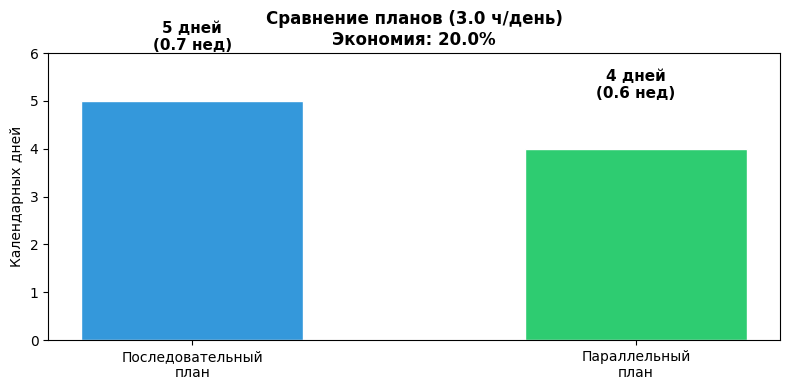

Последовательно: 5 дней = 0.7 нед
Параллельно:     4 дней = 0.6 нед
Экономия:        20.0%


In [8]:
gantt_seq,  days_seq  = build_trajectory(df, [], DEMO_DAILY_HOURS, 52, DEMO_START, parallel_mode=False)
gantt_par,  days_par  = build_trajectory(df, [], DEMO_DAILY_HOURS, 52, DEMO_START, parallel_mode=True)

saving = (1 - days_par / days_seq) * 100 if days_seq > 0 else 0

fig_cmp, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Последовательный\nплан', 'Параллельный\nплан'],
              [days_seq, days_par],
              color=['#3498db', '#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [days_seq, days_par]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val} дней\n({val/7:.1f} нед)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Календарных дней')
ax.set_title(f'Сравнение планов ({DEMO_DAILY_HOURS} ч/день)\nЭкономия: {saving:.1f}%', fontweight='bold')
ax.set_ylim(0, max(days_seq, days_par) * 1.2)
plt.tight_layout()
plt.savefig(REPORTS / 'trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Последовательно: {days_seq} дней = {days_seq/7:.1f} нед')
print(f'Параллельно:     {days_par} дней = {days_par/7:.1f} нед')
print(f'Экономия:        {saving:.1f}%')

## 6. Экспорт отчёта траектории в HTML

In [9]:
def export_trajectory_report(gantt_df, total_days, daily_hours, start_date, deadline):
    fits = (start_date + timedelta(days=total_days)) <= deadline
    status_color = '#27ae60' if fits else '#e74c3c'
    status_text  = 'Укладывается в срок ✓' if fits else 'НЕ укладывается в срок ✗'

    rows_html = ''
    for _, row in gantt_df.iterrows():
        days = (row['Конец'] - row['Начало']).days
        rows_html += (
            f'<tr><td>{row["Предмет"]}</td><td>{row["Поток"]}</td>'
            f'<td>{row["Начало"].date()}</td><td>{row["Конец"].date()}</td>'
            f'<td>{days}</td><td>{row["Часов"]}</td><td>{row["Материалов"]}</td></tr>'
        )

    graph_path = REPORTS / 'trajectory_graph.html'
    graph_note = f'<p><b>???? ??????????:</b> <a href="{graph_path.name}" target="_blank">{graph_path.name}</a></p>' if graph_path.exists() else ''

    html = f"""
    <!DOCTYPE html><html><head><meta charset="utf-8">
    <title>Траектория обучения</title>
    <style>
      body {{ font-family: Arial, sans-serif; margin: 40px; color: #333; }}
      h1 {{ color: #2c3e50; }}
      .kpi {{ display: flex; gap: 20px; margin: 20px 0; flex-wrap: wrap; }}
      .kpi-card {{ background: #f8f9fa; border-left: 4px solid #3498db;
                   padding: 15px 20px; border-radius: 4px; min-width: 160px; }}
      .kpi-value {{ font-size: 28px; font-weight: bold; color: #2c3e50; }}
      .kpi-label {{ font-size: 12px; color: #7f8c8d; margin-top: 4px; }}
      .status {{ color: {status_color}; font-weight: bold; font-size: 18px; margin: 16px 0; }}
      table {{ border-collapse: collapse; width: 100%; margin-top: 20px; }}
      th {{ background: #2c3e50; color: white; padding: 10px; text-align: left; }}
      tr:nth-child(even) {{ background: #f2f2f2; }}
      td {{ padding: 8px 10px; border-bottom: 1px solid #ddd; }}
    </style></head><body>
    <h1>Индивидуальная траектория обучения</h1>
    <p>Сформировано: {datetime.now().strftime('%d.%m.%Y %H:%M')}</p>
    <div class="kpi">
      <div class="kpi-card"><div class="kpi-value">{daily_hours}</div><div class="kpi-label">часов в день</div></div>
      <div class="kpi-card"><div class="kpi-value">{total_days}</div><div class="kpi-label">расчётных дней</div></div>
      <div class="kpi-card"><div class="kpi-value">{total_days//7}</div><div class="kpi-label">недель</div></div>
      <div class="kpi-card"><div class="kpi-value">{len(gantt_df)}</div><div class="kpi-label">предметов</div></div>
      <div class="kpi-card"><div class="kpi-value">{start_date.strftime('%d.%m.%y')}</div><div class="kpi-label">дата начала</div></div>
      <div class="kpi-card"><div class="kpi-value">{deadline.strftime('%d.%m.%y')}</div><div class="kpi-label">дедлайн</div></div>
    </div>
    <div class="status">{status_text}</div>
    {graph_note}
    <table>
      <tr><th>Предмет</th><th>Группа</th><th>Начало</th><th>Конец</th>
          <th>Дней</th><th>Часов</th><th>Материалов</th></tr>
      {rows_html}
    </table></body></html>
    """

    out = REPORTS / 'trajectory_report.html'
    out.write_text(html, encoding='utf-8')
    print(f'Отчёт сохранён: {out}')

export_trajectory_report(gantt_demo, total_days_demo, DEMO_DAILY_HOURS,
                         DEMO_START, deadline_demo)

Отчёт сохранён: ..\reports\trajectory_report.html
